In [48]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [66]:
data = load_breast_cancer()

x = pd.DataFrame(
    data.data,
    columns = data.feature_names
)

y = pd.Series(
    (data.target == 0).astype(int),
    name = "benign"
)

print(y.value_counts())

print("\nFeature matrix shape : ", x.shape)
print("Target shape : ", y.shape)
print("Class names : ", data.target_names)

benign
0    357
1    212
Name: count, dtype: int64

Feature matrix shape :  (569, 30)
Target shape :  (569,)
Class names :  ['malignant' 'benign']


In [67]:
x

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [68]:
y

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: benign, Length: 569, dtype: int64

In [69]:
#Examine the class distribution

class_counts = y.value_counts().sort_index()
class_distribution = pd.DataFrame({
    "Class" : data.target_names,
    "Count" : class_counts.values,
    "Probability" : class_counts.values / len(y)
})

print(class_distribution)

       Class  Count  Probability
0  malignant    357     0.627417
1     benign    212     0.372583


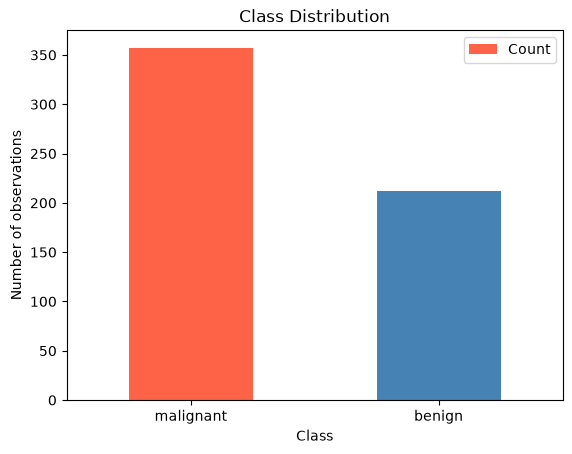

In [70]:
class_distribution.plot(
    x = "Class",
    y = "Count",
    kind = "bar",
    legend = "False",
    color = ["tomato", "steelblue"]
)

plt.ylabel("Number of observations")
plt.title("Class Distribution")
plt.xticks(rotation = 0)
plt.show()

In [71]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.20,
    random_state = 42,
    stratify = y
    )

print("Training size : ", len(y_train))
print("Testing size : ", len(y_test))

print("\nTraining Proportions : ")
print(y_train.value_counts(normalize = True).sort_index())

print("\nTesting Proportions : ")
print(y_test.value_counts(normalize = True).sort_index())

Training size :  455
Testing size :  114

Training Proportions : 
benign
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Testing Proportions : 
benign
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [72]:
#Train a Logistic Regression Model

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter = 1000)
)

model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['mean radius','mean texture','mean perimeter',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [73]:
#Obtain predicted probabilities

probabilities = model.predict_proba(x_test)

print(probabilities[:5])

[[9.99635432e-01 3.64568116e-04]
 [1.07465986e-08 9.99999989e-01]
 [9.57432053e-01 4.25679471e-02]
 [4.23812678e-01 5.76187322e-01]
 [4.90844511e-01 5.09155489e-01]]


In [74]:
print(probabilities[:5].sum(axis = 1))

[1. 1. 1. 1. 1.]


In [58]:
results = pd.DataFrame({
    "Actual_label" : y_test.values,
    "P_malignant" : probabilities[:, 0],
    "P_benign" : probabilities[:, 1]
    })

print(results.head(10))

   Actual_label   P_malignant  P_benign
0             0  9.996354e-01  0.000365
1             1  1.074660e-08  1.000000
2             0  9.574321e-01  0.042568
3             1  4.238127e-01  0.576187
4             0  4.908445e-01  0.509155
5             0  9.993840e-01  0.000616
6             1  2.384659e-01  0.761534
7             0  9.989878e-01  0.001012
8             0  9.994313e-01  0.000569
9             0  9.892324e-01  0.010768


In [59]:
results

,Actual_label,P_malignant,P_benign
0,0,9.996354e-01,0.000365
1,1,1.074660e-08,1.000000
2,0,9.574321e-01,0.042568
3,1,4.238127e-01,0.576187
4,0,4.908445e-01,0.509155
...,...,...,...
109,0,9.998799e-01,0.000120
110,0,9.996350e-01,0.000365
111,0,8.844442e-01,0.115556
112,1,5.083901e-01,0.491610


In [60]:
threshold = 0.50

results["Predicted_malignant"] = (
    results["P_malignant"] >= threshold). astype(int)

results["Predicted_label"] = results[
    "Predicted_malignant"
].map({
    0 : "Malignant",
    1 : "Benign"
})

print(
    results[
        [
            "Actual_label",
            "P_malignant",
            "Predicted_label"
        ]
    ].head(10)
)


   Actual_label   P_malignant Predicted_label
0             0  9.996354e-01          Benign
1             1  1.074660e-08       Malignant
2             0  9.574321e-01          Benign
3             1  4.238127e-01       Malignant
4             0  4.908445e-01       Malignant
5             0  9.993840e-01          Benign
6             1  2.384659e-01       Malignant
7             0  9.989878e-01          Benign
8             0  9.994313e-01          Benign
9             0  9.892324e-01          Benign


In [61]:
for threshold in [0.30, 0.50, 0.70]:
    predcitions = (
        results["P_malignant"] >= threshold
    ).astype(int)
    
    print(
        f"Threshold = {threshold} : "
        f"Predicted malignant cases = {predcitions.sum()}"
    )

Threshold = 0.3 : Predicted malignant cases = 76
Threshold = 0.5 : Predicted malignant cases = 74
Threshold = 0.7 : Predicted malignant cases = 72


In [62]:
actual_malignant = (y_test.values == 0).astype(int)

for threshold in [0.30, 0.50, 0.70]:
    predicted_malignant = (
        probabilities[:, 0] >= threshold
    ).astype(int)
    
    cm = confusion_matrix(
        actual_malignant,
        predicted_malignant
    )
    
    print(f"\nThreshold = {threshold}")
    print(cm)


Threshold = 0.3
[[38  4]
 [ 0 72]]

Threshold = 0.5
[[39  3]
 [ 1 71]]

Threshold = 0.7
[[41  1]
 [ 1 71]]


In [65]:
y_pred = model.predict_proba(x_test)

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score   
)

print("Sklearn accuracy : ")
print(accuracy_score(y_test, y_pred))

Sklearn accuracy : 


ValueError: Classification metrics can't handle a mix of binary and continuous-multioutput targets

In [ ]:
metrics = []